/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

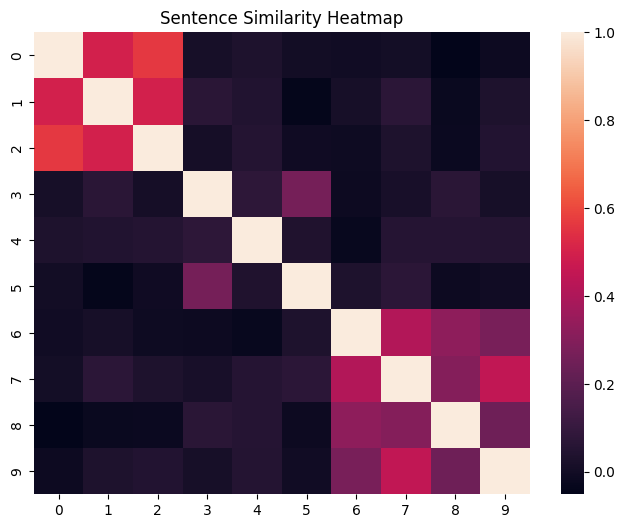

Top similar sentences:
The bowler took a hat trick in the final over 0.677708
The batsman scored a century in the match 0.56821966


In [2]:
!pip install sentence-transformers seaborn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 10 Sentences (3 topics)

sentences = [

# Cricket
"The batsman scored a century in the match",
"The bowler took a hat trick in the final over",
"The team won the cricket tournament",

# Cooking
"I cooked pasta with tomato sauce",
"Baking a cake requires patience",
"Frying vegetables in olive oil enhances taste",

# Cybersecurity
"Strong passwords protect online accounts",
"Phishing attacks can steal user data",
"Firewalls help prevent unauthorized access",

# extra sentence
"Data encryption keeps information secure"
]

# Load Model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)

# Similarity Matrix
sim_matrix = cosine_similarity(embeddings)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix, annot=False)
plt.title("Sentence Similarity Heatmap")
plt.show()

# Query sentence
query = ["The bowler took three wickets in one over"]
query_embedding = model.encode(query)

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Top 2 similar
top_indices = np.argsort(similarities)[-2:][::-1]

print("Top similar sentences:")
for idx in top_indices:
    print(sentences[idx], similarities[idx])
